In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_fwf("page-block.data")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data

,5,7,35,1.400,.400,.657,2.33,14,23,6,1
0,6,7,42,1.167,0.429,0.881,3.60,18,37,5,1
1,6,18,108,3.000,0.287,0.741,4.43,31,80,7,1
2,5,7,35,1.400,0.371,0.743,4.33,13,26,3,1
3,6,3,18,0.500,0.500,0.944,2.25,9,17,4,1
4,5,8,40,1.600,0.550,1.000,2.44,22,40,9,1
...,...,...,...,...,...,...,...,...,...,...,...
5467,4,524,2096,131.000,0.542,0.603,40.57,136,264,28,2
5468,7,4,28,0.571,0.714,0.929,10.00,20,26,2,1
5469,6,95,570,15.833,0.300,0.911,1.64,171,519,104,1
5470,7,41,287,5.857,0.213,0.801,1.36,61,230,45,1


In [5]:
data.columns=["height","lenght","area","eccen","p_black","p_and","mean_tr","blackpix","blackand","wb_trans","Class"]
data

,height,lenght,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans,Class
0,6,7,42,1.167,0.429,0.881,3.60,18,37,5,1
1,6,18,108,3.000,0.287,0.741,4.43,31,80,7,1
2,5,7,35,1.400,0.371,0.743,4.33,13,26,3,1
3,6,3,18,0.500,0.500,0.944,2.25,9,17,4,1
4,5,8,40,1.600,0.550,1.000,2.44,22,40,9,1
...,...,...,...,...,...,...,...,...,...,...,...
5467,4,524,2096,131.000,0.542,0.603,40.57,136,264,28,2
5468,7,4,28,0.571,0.714,0.929,10.00,20,26,2,1
5469,6,95,570,15.833,0.300,0.911,1.64,171,519,104,1
5470,7,41,287,5.857,0.213,0.801,1.36,61,230,45,1


In [6]:
data.Class = pd.factorize(data.Class)[0] + 1

In [7]:
gb=data.groupby("Class")

In [8]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
      height  lenght  area   eccen  p_black  p_and  mean_tr  blackpix  \
0          6       7    42   1.167    0.429  0.881     3.60        18   
1          6      18   108   3.000    0.287  0.741     4.43        31   
2          5       7    35   1.400    0.371  0.743     4.33        13   
3          6       3    18   0.500    0.500  0.944     2.25         9   
4          5       8    40   1.600    0.550  1.000     2.44        22   
...      ...     ...   ...     ...      ...    ...      ...       ...   
5461      11     147  1617  13.364    0.257  0.761     1.58       416   
5462      11     193  2123  17.545    0.243  0.683     1.59       516   
5468       7       4    28   0.571    0.714  0.929    10.00        20   
5469       6      95   570  15.833    0.300  0.911     1.64       171   
5470       7      41   287   5.857    0.213  0.801     1.36        61   

      blackand  wb_trans  Class  
0           37         5      1  
1           80         7      1  
2           26     

In [9]:
gb.get_group(1)

,height,lenght,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans,Class
0,6,7,42,1.167,0.429,0.881,3.60,18,37,5,1
1,6,18,108,3.000,0.287,0.741,4.43,31,80,7,1
2,5,7,35,1.400,0.371,0.743,4.33,13,26,3,1
3,6,3,18,0.500,0.500,0.944,2.25,9,17,4,1
4,5,8,40,1.600,0.550,1.000,2.44,22,40,9,1
...,...,...,...,...,...,...,...,...,...,...,...
5461,11,147,1617,13.364,0.257,0.761,1.58,416,230,264,1
5462,11,193,2123,17.545,0.243,0.683,1.59,516,451,325,1
5468,7,4,28,0.571,0.714,0.929,10.00,20,26,2,1
5469,6,95,570,15.833,0.300,0.911,1.64,171,519,104,1


In [10]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [11]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [12]:
mean_sum=class_samples["height"].mean() + class_samples["lenght"].mean() + class_samples["area"].mean() + class_samples["eccen"].mean() + class_samples["p_black"].mean() + class_samples["p_and"].mean() + class_samples["mean_tr"].mean() + class_samples["blackpix"].mean() + class_samples["blackand"].mean() + class_samples["wb_trans"].mean()

In [13]:
column_length=len(data.columns) -1

In [14]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

210.15063999999998


In [15]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [16]:
mean_sum_2=class_2_samples["height"].mean() + class_2_samples["lenght"].mean() + class_2_samples["area"].mean() + class_2_samples["eccen"].mean() + class_2_samples["p_black"].mean() + class_2_samples["p_and"].mean() + class_2_samples["mean_tr"].mean() + class_2_samples["blackpix"].mean() + class_2_samples["blackand"].mean() + class_2_samples["wb_trans"].mean()

In [17]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

94.76521333333334


In [18]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [19]:
mean_sum_3=class_3_samples["height"].mean() + class_3_samples["lenght"].mean() + class_3_samples["area"].mean() + class_3_samples["eccen"].mean() + class_3_samples["p_black"].mean() + class_3_samples["p_and"].mean() + class_3_samples["mean_tr"].mean() + class_3_samples["blackpix"].mean() + class_3_samples["blackand"].mean() + class_3_samples["wb_trans"].mean()

In [20]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

84.92371999999997


In [21]:
class_4_samples=gb.get_group(4).sample(n=15)

In [22]:
mean_sum_4=class_4_samples["height"].mean() + class_4_samples["lenght"].mean() + class_4_samples["area"].mean() + class_4_samples["eccen"].mean() + class_4_samples["p_black"].mean() + class_4_samples["p_and"].mean() + class_4_samples["mean_tr"].mean() + class_4_samples["blackpix"].mean() + class_4_samples["blackand"].mean() + class_4_samples["wb_trans"].mean()

In [23]:
similar_val_4=mean_sum_4/column_length
print(similar_val_4)

326.51012000000003


In [24]:
class_5_samples=gb.get_group(5).sample(n=15)

In [25]:
mean_sum_5=class_5_samples["height"].mean() + class_5_samples["lenght"].mean() + class_5_samples["area"].mean() + class_5_samples["eccen"].mean() + class_5_samples["p_black"].mean() + class_5_samples["p_and"].mean() + class_5_samples["mean_tr"].mean() + class_5_samples["blackpix"].mean() + class_5_samples["blackand"].mean() + class_5_samples["wb_trans"].mean()

In [26]:
similar_val_5=mean_sum_5/column_length
print(similar_val_5)

536.0224666666667


In [27]:
sim_23=abs(similar_val_3 - similar_val_2)
sim_23=sim_23/1000
sim_23=1 - sim_23

sim_24=abs(similar_val_2 - similar_val_4)
sim_24=sim_24/1000
sim_24=1 - sim_24

sim_25=abs(similar_val_2 - similar_val_5)
sim_25=sim_25/1000
sim_25=1 - sim_25

sim_12=abs(similar_val_1 - similar_val_2)
sim_12=sim_12/1000
sim_12=1 - sim_12

sim_13=abs(similar_val_3 - similar_val_1)
sim_13=sim_13/1000
sim_13=1 - sim_13

sim_14=abs(similar_val_1 - similar_val_4)
sim_14=sim_12/1000
sim_14=1 - sim_14

sim_15=abs(similar_val_1 - similar_val_5)
sim_15=sim_13/1000
sim_15=1 - sim_15

sim_34=abs(similar_val_3 - similar_val_4)
sim_34=sim_34/1000
sim_34=1 - sim_34

sim_35=abs(similar_val_3 - similar_val_5)
sim_35=sim_35/1000
sim_35=1 - sim_35

sim_45=abs(similar_val_4 - similar_val_5)
sim_45=sim_45/1000
sim_45=1 - sim_45




print("Similarity between 1 and 2: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)
print("Similarity between 1 and 4: ", sim_14)
print("Similarity between 1 and 5: ", sim_15)

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 4: ", sim_24)
print("Similarity between 2 and 5: ", sim_25)

print("Similarity between 3 and 4: ", sim_34)
print("Similarity between 3 and 5: ", sim_35)

print("Similarity between 4 and 5: ", sim_45)

Similarity between 1 and 2:  0.8846145733333334
Similarity between 1 and 3:  0.87477308
Similarity between 1 and 4:  0.9991153854266667
Similarity between 1 and 5:  0.99912522692
Similarity between 2 and 3:  0.9901585066666666
Similarity between 2 and 4:  0.7682550933333333
Similarity between 2 and 5:  0.5587427466666667
Similarity between 3 and 4:  0.7584135999999999
Similarity between 3 and 5:  0.5489012533333333
Similarity between 4 and 5:  0.7904876533333334


In [28]:
gb.size()

Class
1    4912
2     329
3      88
4     115
5      28
dtype: int64

In [29]:
m=math.ceil((4912+28)/2)

In [30]:
print(m)

2470


In [31]:
len(gb)

5

In [32]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [33]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [34]:
result=neigh.kneighbors(data, return_distance=True)

In [35]:
print(type(result))

<class 'tuple'>


In [36]:
print(result)

(array([[ 0.        ,  1.55662327,  3.38054981,  4.76113075,  4.81901785],
       [ 0.        ,  6.82142646, 10.50298034, 10.77408507, 10.78463231],
       [ 0.        ,  4.52385455,  4.79669021,  5.30666232,  5.62247036],
       ...,
       [ 0.        , 14.90074713, 16.8236817 , 27.75118855, 28.53150297],
       [ 0.        ,  6.48188692, 11.87752832, 13.30466738, 17.02951849],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]]), array([[   0,   13,   15, 2573, 3330],
       [   1,  134,  314, 2061, 3837],
       [   2,   12, 1487,  227,  285],
       ...,
       [5469, 4969, 4914, 4950, 4934],
       [5470, 1584, 5159, 1552, 1559],
       [4389, 5407, 5010, 2484, 4409]], dtype=int64))


In [37]:
arr1=result[0]

In [38]:
print(type(arr1))

<class 'numpy.ndarray'>


In [39]:
print(arr1.ndim)

2


In [40]:
arr2=result[1]

In [41]:
print(type(arr2))

<class 'numpy.ndarray'>


In [42]:
print(arr1.ndim)

2


In [43]:
print(arr2)

[[   0   13   15 2573 3330]
 [   1  134  314 2061 3837]
 [   2   12 1487  227  285]
 ...
 [5469 4969 4914 4950 4934]
 [5470 1584 5159 1552 1559]
 [4389 5407 5010 2484 4409]]


In [44]:
print(arr1)

[[ 0.          1.55662327  3.38054981  4.76113075  4.81901785]
 [ 0.          6.82142646 10.50298034 10.77408507 10.78463231]
 [ 0.          4.52385455  4.79669021  5.30666232  5.62247036]
 ...
 [ 0.         14.90074713 16.8236817  27.75118855 28.53150297]
 [ 0.          6.48188692 11.87752832 13.30466738 17.02951849]
 [ 0.          0.          0.          0.          0.        ]]


In [45]:
#print(arr1)

In [46]:
print(arr1.size)

27360


In [47]:
#tHIS LINE TAKES THE SUMMATION OF A THE DISTANCE BETWEEN THE INSTANCE AND IT'S NEIGHBORS
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         1.55662327 3.38054981 4.76113075 4.81901785]   14  
[ 0.          6.82142646 10.50298034 10.77408507 10.78463231]   38  
[0.         4.52385455 4.79669021 5.30666232 5.62247036]   20  
[0.         2.94546024 3.18278746 3.22045587 4.02375757]   13  
[0.         3.01176443 3.05060076 3.35290039 3.65713002]   13  
[0.         2.47980745 2.85982972 3.21618314 3.70031107]   12  
[0.         4.51646167 5.14752465 5.9227914  6.41287338]   21  
[0.         2.06171991 4.83751207 5.19630638 5.20407533]   17  
[0.         4.61047698 5.07290607 5.61550861 6.07666364]   21  
[0.         2.00997512 2.64952826 2.71439146 2.83548938]   10  
[0.         2.45401263 3.48397776 3.48719572 3.4950505 ]   12  
[0.         7.30828988 8.57375915 8.96716979 9.35257243]   34  
[0.         4.03123319 4.52385455 4.61047698 4.80038967]   17  
[0.         1.55662327 3.00084005 5.27943652 5.36696842]   15  
[ 0.          7.17256056  8.91308824 10.02860923 11.01044631]   37  
[0.         3.00084005 3.38054

[0.         3.4175184  4.40344343 4.65854935 4.92099726]   17  
[ 0.         13.34267312 15.68503777 25.02092025 33.03095336]   87  
[ 0.          7.07144328 11.83823234 13.07783621 15.07586303]   47  
[ 0.         23.69221579 24.19153604 25.25978325 28.56596928]   101  
[ 0.         21.56498841 28.91376371 37.1221046  38.18580685]   125  
[ 0.         31.01665014 39.94477844 54.46195756 84.40807445]   209  
[ 0.         22.29501839 37.01395923 48.69604887 48.93973206]   156  
[ 0.         23.36683549 36.0261161  36.57964377 42.56135606]   138  
[ 0.         54.25785088 56.46360507 65.93479399 73.64916076]   250  
[0.         1.74104853 2.         2.2519436  2.69607455]   8  
[ 0.          4.12845056  9.70876789 11.27176375 11.61955085]   36  
[ 0.          5.19805204 13.46120964 13.52999575 13.67545849]   45  
[ 0.          6.40468266  9.54085709  9.85914012 12.88579097]   38  
[ 0.         12.7393961  16.64375541 17.6647103  19.35035372]   66  
[ 0.          9.7157185  13.7177063  17

[ 0.         19.34810195 21.02382708 22.61304526 28.89880797]   91  
[0.         7.00143021 7.54957012 7.59317523 8.0762287 ]   30  
[ 0.         11.03936674 11.97111248 12.26670913 13.59731834]   48  
[ 0.          8.54462082 31.20915725 34.85627167 34.90534296]   109  
[  0.          93.62227096  94.23705358 103.31191124 104.62602115]   395  
[0.         6.38051573 8.38918482 9.10007692 9.1483857 ]   33  
[0.         3.74711676 4.39045556 5.45689005 9.34462947]   22  
[ 0.         57.56551567 58.98732312 63.11049771 63.43510464]   243  
[  0.         352.2431467  509.94520517 539.57314343 571.43646419]   1973  
[  0.         230.93858035 344.66792591 404.16321802 404.28773031]   1384  
[ 0.          3.16228778  7.88135141  8.52977127 12.02426917]   31  
[0.         4.12410354 5.20480787 7.07363591 7.35635045]   23  
[ 0.         21.33261585 30.7584407  31.65663512 50.17044971]   133  
[ 0.         11.19764663 17.04630667 17.20490189 17.64208644]   63  
[ 0.         27.33138566 36.125

[0.         2.53181753 8.06116183 8.09210708 8.46238365]   27  
[0.         1.00847459 1.72061646 3.71272703 3.77422177]   10  
[0.         1.49402142 1.72061646 2.17171936 3.04576838]   8  
[0.         3.46428867 7.34846923 9.79795897 9.8488578 ]   30  
[0.        0.        1.4159947 1.4159947 1.4159947]   4  
[ 0.          3.000096   11.0463795  12.25778789 12.26331668]   38  
[ 0.         13.91309764 14.88733818 18.12525211 19.05394043]   65  
[ 0.          6.41274044  7.21700242 14.05836964 15.52663135]   43  
[ 0.         14.90144131 31.41680972 39.02577802 41.79808064]   127  
[ 0.          5.74628228  5.91610826  7.62790804 12.2080779 ]   31  
[  0.         355.48574804 481.40038786 500.88914791 513.1014839 ]   1850  
[ 0.         11.35799718 11.70479239 27.67777917 37.28291257]   88  
[ 0.         22.72021193 25.08513532 29.68706287 32.97333112]   110  
[ 0.         13.11567711 22.33923334 23.24067224 23.57967718]   82  
[ 0.         11.59783536 12.35017206 12.38320532 12.62784

[ 0.         53.69606358 75.62494915 77.62666188 79.99596994]   286  
[ 0.          9.86760807 11.71121433 13.71851938 14.57627693]   49  
[0.         0.         0.         0.         2.23607603]   2  
[ 0.         33.18574467 35.43655375 40.27988175 42.6125746 ]   151  
[ 0.         17.2945429  19.95106887 36.81069184 37.9806571 ]   112  
[ 0.         11.83896098 21.19770688 24.00315111 27.42806204]   84  
[ 0.         10.38920161 12.83065661 16.03891094 16.73468595]   55  
[ 0.         57.38567534 60.34940233 80.14374256 81.56570933]   279  
[0.         5.9467323  6.47811593 7.46080498 7.49916395]   27  
[0.         2.23607156 2.23607156 2.23607156 4.47214311]   11  
[ 0.         38.36460392 39.26310301 39.84044735 41.2004524 ]   158  
[ 0.         30.928349   47.7123295  70.39819214 81.16010513]   230  
[ 0.         25.41900175 28.8048857  29.88262052 31.62586424]   115  
[  0.          40.58661534  86.69270064  95.70969256 101.5922341 ]   324  
[ 0.         26.5169113  30.44914472 

...

[  0.          49.15298897  68.25703928  84.34461622 110.0889725 ]   311  
[  0.         228.93813175 286.09445522 297.69649034 324.09852886]   1136  
[0.         3.77365287 4.3292929  4.64854407 5.13785714]   17  
[ 0.         15.18688329 24.62500307 26.63561661 27.2715785 ]   93  
[0.         0.         0.         0.         2.23607603]   2  
[  0.         387.5338801  409.90422129 416.63310844 513.66416629]   1727  
[ 0.         32.30950209 35.94498832 35.96097507 37.19157739]   141  
[0. 0. 0. 1. 1.]   2  
[ 0.         18.13837589 23.15651245 30.10213562 32.71733762]   104  
[ 0.         42.76883499 53.54592456 62.44259009 81.62264414]   240  
[ 0.         17.41928153 22.59771769 48.88249719 50.08044351]   138  
[ 0.          6.74385505 15.92178696 16.00013612 18.65414595]   57  
[  0.         274.48648396 280.30526024 328.37823522 372.21969121]   1255  
[  0.         201.540339   225.32970652 253.52626576 258.59376741]   938  
[ 0.          2.31261346  3.38168774  6.7112516  11.48

[ 0.          3.8173737  12.36193387 13.08996868 13.28918873]   42  
[  0.         181.88757632 193.88679142 236.5519798  264.67468845]   877  
[  0.         140.506131   147.85714405 219.2316198  231.04549507]   738  
[  0.         140.88655386 147.69735521 155.81698309 171.22213542]   615  
[0.         4.24046507 4.94737718 5.04878639 6.19834365]   20  
[  0.         179.34620806 273.71088768 289.85903373 297.31503635]   1040  
[ 0.         57.39416617 72.20994802 76.99361133 94.25903487]   300  
[ 0.          2.25484478 17.85349826 18.1379533  19.2979246 ]   57  
[  0.         237.58257615 254.00176579 271.98409335 299.83866575]   1063  
[  0.         234.17902139 304.53191973 374.52060746 379.69763264]   1292  
[ 0.         29.76877878 30.53169732 35.66716643 39.69770826]   135  
[ 0.          7.56273714  8.00806138  8.40655536 10.83950202]   34  
[  0.         133.57727664 141.08175826 153.94821105 157.99654638]   586  
[ 0.         28.29031428 33.15754566 44.34146756 50.78266028]

[  0.          92.38000975 113.73447673 145.78840688 165.91813889]   517  
[ 0.          9.05648144 18.49948088 19.23655939 28.93327691]   75  
[ 0.         36.27215455 42.22498154 43.71483846 46.93436151]   169  
[ 0.         17.46543856 19.80446854 19.87533597 21.91149308]   79  
[ 0.         32.68293582 33.02129159 37.79119301 37.86614941]   141  
[  0.         193.48492033 200.07478375 280.23526503 302.27923475]   976  
[ 0.         35.22815892 37.60473686 37.64311567 42.06326713]   152  
[ 0.         13.78537921 21.95635885 23.17603547 24.65985503]   83  
[  0.         130.82472588 132.50806202 133.97852733 148.89227486]   546  
[ 0.          9.95001412 16.73907115 25.90574351 30.05274082]   82  
[ 0.         34.56276097 36.1874147  40.21173683 41.95843881]   152  
[ 0.         31.57535526 35.11439346 36.45623268 36.9611492 ]   140  
[ 0.         23.49953763 25.18031757 25.53600245 25.82922045]   100  
[  0.          75.5842941  102.86442861 105.17145673 142.66845488]   426  
[ 0.

[ 0.          7.35127316  9.68503123 11.46185775 11.56866453]   40  
[ 0.          7.8793607   9.622458   11.27404209 14.43657113]   43  
[ 0.         21.19561865 24.77917452 27.0638074  29.46735877]   102  
[ 0.          7.88095515 10.54363965 10.58586274 10.91855631]   39  
[ 0.         16.6283651  20.97708848 29.2551517  31.15921398]   98  
[0.         4.36802896 5.04181862 7.46397542 9.43665878]   26  
[ 0.         80.07594219 81.71825207 94.86119702 97.01907322]   353  
[ 0.         14.24923026 15.45722592 15.8084053  19.29470116]   64  
[ 0.          9.86439304 14.62998835 15.19628919 19.33983376]   59  
[ 0.         14.59496519 20.54839152 27.92850123 32.86468447]   95  
[ 0.         32.8310161  52.64768213 55.17022552 58.08940218]   198  
[ 0.         34.7485825  45.69691195 66.24039207 78.57362995]   225  
[0.         1.7397563  2.51525347 2.66475215 3.01351622]   9  
[  0.          73.42449162  86.36099271  92.5150318  116.06538833]   368  
[ 0.         73.81776115 81.7595450

[ 0.          9.25773855  9.59804866 10.03978541 10.32875772]   39  
[  0.         148.29395241 154.27549814 175.72603305 176.69772684]   654  
[ 0.         32.95303843 33.14101552 35.74109057 35.76362395]   137  
[ 0.         16.91126849 18.41143093 19.15910689 22.09828177]   76  
[ 0.         21.76620199 27.94682456 34.14704746 38.91151811]   122  
[ 0.         24.0093139  25.04375501 26.30177732 27.99358796]   103  
[0.         2.64608465 6.08373643 8.16431896 8.96791637]   25  
[ 0.          6.42204243  9.04354195 10.15712095 12.3315377 ]   37  
[ 0.         42.74615611 54.434492   64.76464881 72.21467051]   234  
[  0.          45.14553204  86.06152972  96.57243728 102.96890483]   330  
[ 0.         20.83280351 22.52084175 27.36965446 28.27326159]   98  
[  0.         108.00741658 118.68425047 126.84170391 138.20607572]   491  
[  0.          81.73478766  88.34311154  93.58164466 123.06349993]   386  
[ 0.         33.12720172 42.05355212 42.92902758 44.08319569]   162  
[  0.     

In [48]:
print(len(addVal))

5472


In [49]:
#THE VALUE FOR THE SUMMATION OF ALL THE DISTANCES
print(addVal)

[14, 38, 20, 13, 13, 12, 21, 17, 21, 10, 12, 34, 17, 15, 37, 15, 60, 11, 18, 18, 30, 27, 14, 19, 192, 134, 32, 153, 40, 19, 40, 23, 104, 184, 342, 26, 203, 39, 58, 36, 85, 123, 687, 30, 35, 25, 60, 103, 115, 38, 118, 10, 89, 51, 80, 156, 220, 28, 89, 113, 118, 130, 10, 156, 174, 42, 155, 146, 103, 70, 126, 40, 41, 100, 71, 138, 44, 41, 78, 141, 73, 181, 3, 6, 0, 17, 25, 24, 57, 184, 103, 20, 20, 176, 539, 93, 134, 35, 37, 32, 98, 116, 45, 237, 184, 166, 45, 116, 345, 115, 63, 65, 40, 76, 60, 214, 24, 328, 14, 0, 230, 110, 126, 53, 53, 6, 502, 339, 332, 169, 46, 214, 6, 55, 34, 138, 153, 19, 30, 89, 6, 35, 35, 37, 164, 17, 25, 10, 37, 29, 32, 52, 41, 27, 50, 33, 29, 86, 89, 49, 42, 112, 63, 40, 53, 118, 103, 46, 120, 91, 159, 105, 61, 87, 149, 127, 104, 202, 125, 76, 94, 109, 49, 140, 77, 28, 74, 52, 58, 88, 181, 137, 26, 102, 94, 27, 31, 42, 105, 129, 40, 44, 169, 222, 7, 188, 245, 87, 57, 18, 67, 66, 43, 57, 48, 44, 66, 255, 26, 56, 71, 649, 51, 281, 287, 76, 69, 20, 14, 86, 66, 68, 3

In [50]:
arr3=np.array(addVal)

In [51]:
print(type(arr3))

<class 'numpy.ndarray'>


In [52]:
print(arr3.size)

5472


In [53]:
print(arr3)

[14 38 20 ... 88 48  0]


In [54]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   14
2   38
3   20
4   13
5   13
6   12
7   21
8   17
9   21
10   10
11   12
12   34
13   17
14   15
15   37
16   15
17   60
18   11
19   18
20   18
21   30
22   27
23   14
24   19
25   192
26   134
27   32
28   153
29   40
30   19
31   40
32   23
33   104
34   184
35   342
36   26
37   203
38   39
39   58
40   36
41   85
42   123
43   687
44   30
45   35
46   25
47   60
48   103
49   115
50   38
51   118
52   10
53   89
54   51
55   80
56   156
57   220
58   28
59   89
60   113
61   118
62   130
63   10
64   156
65   174
66   42
67   155
68   146
69   103
70   70
71   126
72   40
73   41
74   100
75   71
76   138
77   44
78   41
79   78
80   141
81   73
82   181
83   3
84   6
85   0
86   17
87   25
88   24
89   57
90   184
91   103
92   20
93   20
94   176
95   539
96   93
97   134
98   35
99   37
100   32
101   98
102   116
103   45
104   237
105   184
106   166
107   45
108   116
109   345
110   115
111   63
112   65
113   40
114   76
115   60
116   214
117   24
118   328
119   14

905   37
906   18
907   38
908   116
909   97
910   55
911   154
912   217
913   244
914   118
915   200
916   67
917   69
918   46
919   49
920   46
921   55
922   49
923   55
924   1165
925   1286
926   173
927   110
928   205
929   6
930   0
931   343
932   84
933   853
934   98
935   1570
936   267
937   119
938   401
939   64
940   64
941   316
942   136
943   120
944   74
945   198
946   114
947   63
948   84
949   41
950   67
951   58
952   57
953   206
954   541
955   1781
956   1338
957   375
958   20
959   163
960   2
961   15
962   186
963   227
964   6
965   302
966   37
967   525
968   2
969   50
970   6
971   10
972   20
973   198
974   286
975   49
976   2
977   151
978   112
979   84
980   55
981   279
982   27
983   11
984   158
985   230
986   115
987   324
988   123
989   124
990   195
991   148
992   181
993   83
994   89
995   139
996   156
997   161
998   163
999   279
1000   166
1001   1435
1002   1118
1003   1060
1004   995
1005   225
1006   1088
1007   1543
100

1880   12
1881   31
1882   11
1883   19
1884   40
1885   8
1886   15
1887   16
1888   30
1889   37
1890   76
1891   34
1892   15
1893   32
1894   23
1895   73
1896   6
1897   30
1898   72
1899   7
1900   51
1901   98
1902   27
1903   39
1904   18
1905   25
1906   6
1907   25
1908   28
1909   20
1910   21
1911   23
1912   34
1913   18
1914   35
1915   48
1916   19
1917   22
1918   26
1919   55
1920   14
1921   10
1922   59
1923   39
1924   36
1925   67
1926   31
1927   18
1928   25
1929   9
1930   39
1931   44
1932   96
1933   21
1934   21
1935   22
1936   42
1937   50
1938   12
1939   10
1940   16
1941   22
1942   26
1943   147
1944   20
1945   56
1946   7
1947   42
1948   54
1949   177
1950   70
1951   41
1952   33
1953   41
1954   14
1955   15
1956   54
1957   30
1958   24
1959   12
1960   23
1961   39
1962   23
1963   24
1964   84
1965   24
1966   16
1967   21
1968   34
1969   16
1970   80
1971   7
1972   67
1973   17
1974   50
1975   9
1976   55
1977   36
1978   25
1979   34
1980  

2728   61
2729   45
2730   13
2731   45
2732   35
2733   47
2734   205
2735   134
2736   25
2737   78
2738   21
2739   88
2740   15
2741   19
2742   4
2743   12
2744   24
2745   25
2746   32
2747   147
2748   250
2749   237
2750   313
2751   89
2752   5
2753   23
2754   12
2755   55
2756   60
2757   80
2758   220
2759   76
2760   74
2761   8
2762   62
2763   45
2764   44
2765   69
2766   52
2767   63
2768   31
2769   16
2770   19
2771   458
2772   440
2773   43
2774   15
2775   49
2776   26
2777   51
2778   93
2779   15
2780   7
2781   28
2782   15
2783   26
2784   10
2785   39
2786   19
2787   14
2788   17
2789   56
2790   21
2791   169
2792   37
2793   55
2794   96
2795   24
2796   22
2797   86
2798   25
2799   67
2800   39
2801   50
2802   82
2803   27
2804   80
2805   21
2806   42
2807   12
2808   68
2809   14
2810   73
2811   57
2812   73
2813   94
2814   49
2815   40
2816   82
2817   60
2818   7
2819   591
2820   348
2821   33
2822   72
2823   79
2824   452
2825   51
2826   27
28

3759   390
3760   122
3761   462
3762   401
3763   445
3764   482
3765   738
3766   264
3767   195
3768   67
3769   609
3770   223
3771   252
3772   187
3773   91
3774   88
3775   331
3776   150
3777   38
3778   128
3779   323
3780   137
3781   283
3782   410
3783   177
3784   27
3785   242
3786   316
3787   52
3788   570
3789   442
3790   18
3791   153
3792   670
3793   172
3794   435
3795   564
3796   16
3797   6
3798   95
3799   18
3800   45
3801   124
3802   214
3803   412
3804   115
3805   620
3806   418
3807   93
3808   999
3809   945
3810   549
3811   248
3812   757
3813   164
3814   188
3815   78
3816   125
3817   95
3818   225
3819   171
3820   210
3821   165
3822   149
3823   341
3824   332
3825   195
3826   232
3827   849
3828   27
3829   266
3830   42
3831   500
3832   945
3833   30
3834   604
3835   301
3836   35
3837   464
3838   38
3839   63
3840   1478
3841   21
3842   1189
3843   31
3844   173
3845   647
3846   67
3847   21
3848   282
3849   789
3850   112
3851   239
3

4880   368
4881   411
4882   468
4883   208
4884   107
4885   829
4886   137
4887   99
4888   318
4889   84
4890   477
4891   61
4892   428
4893   78
4894   330
4895   180
4896   149
4897   1231
4898   170
4899   103
4900   150
4901   336
4902   159
4903   170
4904   97
4905   89
4906   106
4907   476
4908   132
4909   16
4910   394
4911   136
4912   114
4913   453
4914   74
4915   97
4916   92
4917   72
4918   73
4919   427
4920   106
4921   517
4922   75
4923   169
4924   79
4925   141
4926   976
4927   152
4928   83
4929   546
4930   82
4931   152
4932   140
4933   100
4934   426
4935   95
4936   82
4937   347
4938   248
4939   89
4940   91
4941   23
4942   75
4943   509
4944   123
4945   92
4946   565
4947   99
4948   429
4949   85
4950   72
4951   102
4952   118
4953   180
4954   109
4955   195
4956   117
4957   85
4958   501
4959   204
4960   95
4961   226
4962   95
4963   445
4964   116
4965   116
4966   468
4967   136
4968   161
4969   73
4970   87
4971   210
4972   104
4973   

In [55]:
newarr = arr3.reshape(5472, 1)

In [56]:
print(newarr.ndim)

2


In [57]:
new_arr2=np.append(arr2, newarr, axis=1)

In [58]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [59]:
#FORM AN ARRAY THAT INCLUDES THE INDICE OF NEIGHBORS AND THE DISTANCE AS THE LAST INDICE
print(new_arr2)

[[   0   13   15 2573 3330   14]
 [   1  134  314 2061 3837   38]
 [   2   12 1487  227  285   20]
 ...
 [5469 4969 4914 4950 4934   88]
 [5470 1584 5159 1552 1559   48]
 [4389 5407 5010 2484 4409    0]]


In [60]:
print(new_arr2[0])

[   0   13   15 2573 3330   14]


In [61]:
arr2

array([[   0,   13,   15, 2573, 3330],
       [   1,  134,  314, 2061, 3837],
       [   2,   12, 1487,  227,  285],
       ...,
       [5469, 4969, 4914, 4950, 4934],
       [5470, 1584, 5159, 1552, 1559],
       [4389, 5407, 5010, 2484, 4409]], dtype=int64)

In [62]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

13 15 2573 3330 14


In [63]:
data

,height,lenght,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans,Class
0,6,7,42,1.167,0.429,0.881,3.60,18,37,5,1
1,6,18,108,3.000,0.287,0.741,4.43,31,80,7,1
2,5,7,35,1.400,0.371,0.743,4.33,13,26,3,1
3,6,3,18,0.500,0.500,0.944,2.25,9,17,4,1
4,5,8,40,1.600,0.550,1.000,2.44,22,40,9,1
...,...,...,...,...,...,...,...,...,...,...,...
5467,4,524,2096,131.000,0.542,0.603,40.57,136,264,28,2
5468,7,4,28,0.571,0.714,0.929,10.00,20,26,2,1
5469,6,95,570,15.833,0.300,0.911,1.64,171,519,104,1
5470,7,41,287,5.857,0.213,0.801,1.36,61,230,45,1


In [64]:
# Creating and populating a dictionary with the 'key' as key and class value as value
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [65]:
#print(new_dist)

In [66]:
# Creating and populating a dictionary with the 's=0 to end' as key and class value as value
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [67]:
#print(new_dist2)

In [68]:
# Creating and populating a dictionary with the 's=0 to end' as key and 'index value' as value
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [69]:
#print(new_dist3)

In [70]:
#print(new_dist[204])

In [71]:
#new_dist3

<!-- Populating a dictionary  -->

In [72]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        c4=0
        c5=0
        class_example=0
        
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        elif int(v) == 3:
            c3=c3+1
        elif int(v) == 4:
            c4=c4+1
        else:
            c5=c5+1
            
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            elif new_dist2[new_arr2[i][x]]==3:
                c3=c3+1
            elif new_dist2[new_arr2[i][x]]==4:
                c4=c4+1
            else:
                c5=c5+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3 + sim_14 * c4 + sim_15 * c5)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3+ sim_24 * c3 + sim_25 * c5)/5
                class_example=2
                safe_level=round(safe_level,2)
            elif int(v) == 3:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3  + sim_34 * c4 + sim_35 * c5)/5
                class_example=3
                safe_level=round(safe_level,2)
            elif int(v) == 4:
                safe_level=(sim_14 * c1 + sim_24 * c2 + sim_34 * c3 + 1 * c4 + sim_35 * c5)/5
                class_example=4
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_15 * c1 + sim_25 * c2   + sim_35 * c3 + sim_45 * c4 + 1 * c5)/5
                class_example=5
                safe_level=round(safe_level,2)
                
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,c4,c5,safe_level,new_arr2[i][5]])
        
        
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [73]:
print(neigh_count)

[[0, 0, 1, 5, 0, 0, 0, 0, 1.0, 14], [1, 1, 1, 5, 0, 0, 0, 0, 1.0, 38], [2, 2, 1, 5, 0, 0, 0, 0, 1.0, 20], [3, 3, 1, 5, 0, 0, 0, 0, 1.0, 13], [4, 4, 1, 5, 0, 0, 0, 0, 1.0, 13], [5, 5, 1, 5, 0, 0, 0, 0, 1.0, 12], [6, 6, 1, 5, 0, 0, 0, 0, 1.0, 21], [7, 7, 1, 5, 0, 0, 0, 0, 1.0, 17], [8, 8, 1, 5, 0, 0, 0, 0, 1.0, 21], [9, 9, 1, 3, 0, 2, 0, 0, 0.95, 10], [10, 10, 1, 5, 0, 0, 0, 0, 1.0, 12], [11, 11, 1, 4, 0, 0, 1, 0, 1.0, 34], [12, 12, 1, 5, 0, 0, 0, 0, 1.0, 17], [13, 13, 1, 5, 0, 0, 0, 0, 1.0, 15], [14, 14, 1, 5, 0, 0, 0, 0, 1.0, 37], [15, 15, 1, 5, 0, 0, 0, 0, 1.0, 15], [16, 16, 1, 3, 0, 0, 2, 0, 1.0, 60], [17, 17, 1, 5, 0, 0, 0, 0, 1.0, 11], [18, 18, 1, 5, 0, 0, 0, 0, 1.0, 18], [19, 19, 1, 5, 0, 0, 0, 0, 1.0, 18], [20, 20, 1, 5, 0, 0, 0, 0, 1.0, 30], [21, 21, 1, 4, 1, 0, 0, 0, 0.98, 27], [22, 22, 1, 5, 0, 0, 0, 0, 1.0, 14], [23, 23, 1, 5, 0, 0, 0, 0, 1.0, 19], [24, 24, 1, 3, 1, 0, 1, 0, 0.98, 192], [25, 25, 1, 5, 0, 0, 0, 0, 1.0, 134], [26, 26, 1, 5, 0, 0, 0, 0, 1.0, 32], [27, 27, 1, 5, 

In [74]:
# iterating a dictionary

In [75]:
# for s in range(149):
#     print(neigh_count[s])

In [76]:
# Converting a dictionary to a dataframe

In [77]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','c_four','c_five','safe_level','distance'])

In [78]:
#print(new_main_df)

In [79]:
new_main_df.set_index("s_no", inplace=True)

In [80]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  c_four  c_five  safe_level  \
s_no                                                                         
0              0      1      5      0        0       0       0        1.00   
1              1      1      5      0        0       0       0        1.00   
2              2      1      5      0        0       0       0        1.00   
3              3      1      5      0        0       0       0        1.00   
4              4      1      5      0        0       0       0        1.00   
...          ...    ...    ...    ...      ...     ...     ...         ...   
5467        5467      2      3      2        0       0       0        0.93   
5468        5468      1      5      0        0       0       0        1.00   
5469        5469      1      5      0        0       0       0        1.00   
5470        5470      1      5      0        0       0       0        1.00   
5471        5471      3      0      0        5       0       0  

In [81]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [82]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [83]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
10 10
11 11
12 12
13 13
14 14
15 15
16 16
17 17
18 18
19 19
20 20
21 21
22 22
23 23
24 24
25 25
26 26
27 27
28 28
29 29
30 30
31 31
32 32
33 33
34 34
35 35
36 36
37 37
38 38
39 39
40 40
41 41
42 42
43 43
44 44
45 45
46 46
47 47
48 48
49 49
50 50
51 51
52 52
53 53
54 54
55 55
56 56
57 57
58 58
59 59
60 60
61 61
62 62
63 63
64 64
65 65
66 66
67 67
68 68
69 69
70 70
71 71
72 72
73 73
74 74
75 75
76 76
77 77
78 78
79 79
80 80
81 81
82 82
83 83
84 84
85 85
86 86
87 87
88 88
89 89
90 90
91 91
92 92
93 93
94 94
95 95
96 96
97 97
98 98
99 99
100 100
101 101
102 102
103 103
104 104
105 105
106 106
107 107
108 108
109 109
110 110
111 111
112 112
113 113
114 114
115 115
116 116
117 117
118 118
119 119
120 120
121 121
122 122
123 123
124 124
125 125
126 126
127 127
128 128
129 129
130 130
131 131
132 132
133 133
134 134
135 135
136 136
137 137
138 138
139 139
140 140
141 141
142 142
143 143
144 144
145 145
146 146
147 147
148 148
149 149
150 150
151 151
152 

1440 1440
1441 1441
1442 1442
1443 1443
1444 1444
1445 1445
1446 1446
1447 1447
1448 1448
1449 1449
1450 1450
1451 1451
1452 1452
1453 1453
1454 1454
1455 1455
1456 1456
1457 1457
1458 1458
1459 1459
1460 1460
1461 1461
1462 1462
1463 1463
1464 1464
1465 1465
1466 1466
1467 1467
1468 1468
1469 1469
1470 1470
1471 1471
1472 1472
1473 1473
1474 1474
1475 1475
1476 1476
1477 1477
1478 1478
1479 1479
1480 1480
1481 1481
1482 1482
1483 1483
1484 1484
1485 1485
1486 1486
1487 1487
1488 1488
1489 1489
1490 1490
1491 1491
1492 1492
1493 1493
1494 1494
1495 1495
1496 1496
1497 1497
1498 1498
1499 1499
1500 1500
1501 1501
1502 1502
1503 1503
1504 1504
1505 1505
1506 1506
1507 1507
1508 1508
1509 1509
1510 1510
1511 1511
1512 1512
1513 1513
1514 1514
1515 1515
1516 1516
1517 1517
1518 1518
1519 1519
1520 1520
1521 1521
1522 1522
1523 1523
1524 1524
1525 1525
1526 1526
1527 1527
1528 1528
1529 1529
1530 1530
1531 1531
1532 1532
1533 1533
1534 1534
1535 1535
1536 1536
1537 1537
1538 1538
1539 1539


2794 2794
2795 2795
2796 2796
2797 2797
2798 2798
2799 2799
2800 2800
2801 2801
2802 2802
2803 2803
2804 2804
2805 2805
2806 2806
2807 2807
2808 2808
2809 2809
2810 2810
2811 2811
2812 2812
2813 2813
2814 2814
2815 2815
2816 2816
2817 2817
2818 2818
2819 2819
2820 2820
2821 2821
2822 2822
2823 2823
2824 2824
2825 2825
2826 2826
2827 2827
2828 2828
2829 2829
2830 2830
2831 2831
2832 2832
2833 2833
2834 2834
2835 2835
2836 2836
2837 2837
2838 2838
2839 2839
2840 2840
2841 2841
2842 2842
2843 2843
2844 2844
2845 2845
2846 2846
2847 2847
2848 2848
2849 2849
2850 2850
2851 2851
2852 2852
2853 2853
2854 2854
2855 2855
2856 2856
2857 2857
2858 2858
2859 2859
2860 2860
2861 2861
2862 2862
2863 2863
2864 2864
2865 2865
2866 2866
2867 2867
2868 2868
2869 2869
2870 2870
2871 2871
2872 2872
2873 2873
2874 2874
2875 2875
2876 2876
2877 2877
2878 2878
2879 2879
2880 2880
2881 2881
2882 2882
2883 2883
2884 2884
2885 2885
2886 2886
2887 2887
2888 2888
2889 2889
2890 2890
2891 2891
2892 2892
2893 2893


4044 4044
4045 4045
4046 4046
4047 4047
4048 4048
4049 4049
4050 4050
4051 4051
4052 4052
4053 4053
4054 4054
4055 4055
4056 4056
4057 4057
4058 4058
4059 4059
4060 4060
4061 4061
4062 4062
4063 4063
4064 4064
4065 4065
4066 4066
4067 4067
4068 4068
4069 4069
4070 4070
4071 4071
4072 4072
4073 4073
4074 4074
4075 4075
4076 4076
4077 4077
4078 4078
4079 4079
4080 4080
4081 4081
4082 4082
4083 4083
4084 4084
4085 4085
4086 4086
4087 4087
4088 4088
4089 4089
4090 4090
4091 4091
4092 4092
4093 4093
4094 4094
4095 4095
4096 4096
4097 4097
4098 4098
4099 4099
4100 4100
4101 4101
4102 4102
4103 4103
4104 4104
4105 4105
4106 4106
4107 4107
4108 4108
4109 4109
4110 4110
4111 4111
4112 4112
4113 4113
4114 4114
4115 4115
4116 4116
4117 4117
4118 4118
4119 4119
4120 4120
4121 4121
4122 4122
4123 4123
4124 4124
4125 4125
4126 4126
4127 4127
4128 4128
4129 4129
4130 4130
4131 4131
4132 4132
4133 4133
4134 4134
4135 4135
4136 4136
4137 4137
4138 4138
4139 4139
4140 4140
4141 4141
4142 4142
4143 4143


In [84]:
new_classes=new_main_df.groupby("Class")

In [85]:
new_classes.size()

Class
1    4912
2     329
3      88
4     115
5      28
dtype: int64

In [86]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

4807 87 18 0


In [87]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

246 44 23 16


In [88]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

66 9 9 4


In [89]:
new_class_4=new_classes.get_group(4)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_4.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 32 6 77


In [90]:
new_class_5=new_classes.get_group(5)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_5.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 7 0 21


In [91]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [92]:
new_gb=new_main_df.groupby("Class")

In [93]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [94]:
gb_1=gb.get_group(1)

In [95]:
gb_2=gb.get_group(2)

In [96]:
gb_3=gb.get_group(3)

In [97]:
gb_4=gb.get_group(4)

In [98]:
gb_5=gb.get_group(5)

In [99]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [100]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [101]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [102]:
new_4=new_gb.get_group(4).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [103]:
new_5=new_gb.get_group(5).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [104]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [105]:
minor_c_1=new_1.sample(n=m, replace='False')

In [106]:
new_gb

In [107]:
gb

In [108]:
minor_c_2=new_2.sample(n=m, replace='True')

In [109]:
minor_c_3=new_3.sample(n=m, replace='True')

In [110]:
minor_c_4=new_4.sample(n=m, replace='True')

In [111]:
minor_c_5=new_5.sample(n=m, replace='False')

In [112]:
maj_c_filtered=[]
for i, row in enumerate(minor_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'height']
    c=gb_1.at[row.real_index, 'lenght']
    d=gb_1.at[row.real_index, 'area']
    e=gb_1.at[row.real_index, 'eccen']
    f=gb_1.at[row.real_index, 'p_black']
    g=gb_1.at[row.real_index, 'p_and']
    h=gb_1.at[row.real_index, 'mean_tr']
    i=gb_1.at[row.real_index, 'blackpix']
    j=gb_1.at[row.real_index, 'blackand']
    k=gb_1.at[row.real_index, 'wb_trans']
    maj_c_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [113]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [114]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'height']
    c=gb_2.at[row.real_index, 'lenght']
    d=gb_2.at[row.real_index, 'area']
    e=gb_2.at[row.real_index, 'eccen']
    f=gb_2.at[row.real_index, 'p_black']
    g=gb_2.at[row.real_index, 'p_and']
    h=gb_2.at[row.real_index, 'mean_tr']
    i=gb_2.at[row.real_index, 'blackpix']
    j=gb_2.at[row.real_index, 'blackand']
    k=gb_2.at[row.real_index, 'wb_trans']
    min_c_2_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [115]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'height']
    c=gb_3.at[row.real_index, 'lenght']
    d=gb_3.at[row.real_index, 'area']
    e=gb_3.at[row.real_index, 'eccen']
    f=gb_3.at[row.real_index, 'p_black']
    g=gb_3.at[row.real_index, 'p_and']
    h=gb_3.at[row.real_index, 'mean_tr']
    i=gb_3.at[row.real_index, 'blackpix']
    j=gb_3.at[row.real_index, 'blackand']
    k=gb_3.at[row.real_index, 'wb_trans']
    min_c_3_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [116]:
#print(min_c_3_filtered)

In [117]:
min_c_4_filtered=[]
for i, row in enumerate(minor_c_4.itertuples(index=True), 0):
    a=gb_4.at[row.real_index, 'Class']
    b=gb_4.at[row.real_index, 'height']
    c=gb_4.at[row.real_index, 'lenght']
    d=gb_4.at[row.real_index, 'area']
    e=gb_4.at[row.real_index, 'eccen']
    f=gb_4.at[row.real_index, 'p_black']
    g=gb_4.at[row.real_index, 'p_and']
    h=gb_4.at[row.real_index, 'mean_tr']
    i=gb_4.at[row.real_index, 'blackpix']
    j=gb_4.at[row.real_index, 'blackand']
    k=gb_4.at[row.real_index, 'wb_trans']
    min_c_4_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [118]:
min_c_5_filtered=[]
for i, row in enumerate(minor_c_5.itertuples(index=True), 0):
    a=gb_5.at[row.real_index, 'Class']
    b=gb_5.at[row.real_index, 'height']
    c=gb_5.at[row.real_index, 'lenght']
    d=gb_5.at[row.real_index, 'area']
    e=gb_5.at[row.real_index, 'eccen']
    f=gb_5.at[row.real_index, 'p_black']
    g=gb_5.at[row.real_index, 'p_and']
    h=gb_5.at[row.real_index, 'mean_tr']
    i=gb_5.at[row.real_index, 'blackpix']
    j=gb_5.at[row.real_index, 'blackand']
    k=gb_5.at[row.real_index, 'wb_trans']
    min_c_5_filtered.append([a,b,c,d,e,f,g,h,i,j,k])

In [119]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','height','lenght','area','eccen','p_black','p_and','mean_tr','blackpix','blackand','wb_trans'])

In [120]:
print(new_maj_c_filtered)

      Class  height  lenght  area   eccen  p_black  p_and  mean_tr  blackpix  \
0         1       7      35   245   5.000    0.408  0.755     2.38       100   
1         1       7     197  1379  28.143    0.072  0.326     1.50        99   
2         1       7     100   700  14.286    0.279  0.980     1.63       195   
3         1       7      35   245   5.000    0.445  0.771     2.48       109   
4         1       7      38   266   5.429    0.414  0.846     2.44       110   
...     ...     ...     ...   ...     ...      ...    ...      ...       ...   
2465      1       9      20   180   2.222    0.300  0.972     1.74        54   
2466      1       8       8    64   1.000    0.359  0.969     1.53        23   
2467      1      13     441  5733  33.923    0.374  0.625     4.63       144   
2468      1       8     121   968  15.125    0.431  0.980     3.11       417   
2469      1       8      16   128   2.000    0.359  0.781     2.00        46   

      blackand  wb_trans  
0          1

In [121]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered, columns=['Class','height','lenght','area','eccen','p_black','p_and','mean_tr','blackpix','blackand','wb_trans'])
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered, columns=['Class','height','lenght','area','eccen','p_black','p_and','mean_tr','blackpix','blackand','wb_trans'])
new_min_c_4_filtered = pd.DataFrame(min_c_4_filtered, columns=['Class','height','lenght','area','eccen','p_black','p_and','mean_tr','blackpix','blackand','wb_trans'])
new_min_c_5_filtered = pd.DataFrame(min_c_5_filtered, columns=['Class','height','lenght','area','eccen','p_black','p_and','mean_tr','blackpix','blackand','wb_trans'])

In [122]:
print(new_min_c_5_filtered)

      Class  height  lenght  area  eccen  p_black  p_and  mean_tr  blackpix  \
0         5      66     472  8352  2.843    0.359  0.547    17.12        93   
1         5      63     161  6243  0.988    0.523  0.897     8.40       725   
2         5      74     471  1954  2.707    0.339  0.433    15.84       820   
3         5      87     141  6367  0.754    0.415  0.884     4.69       947   
4         5      28     347  4416  2.711    0.399  0.567    13.07       721   
...     ...     ...     ...   ...    ...      ...    ...      ...       ...   
2465      5      64      73  4672  1.141    0.403  0.445    72.38       882   
2466      5      63     161  6243  0.988    0.523  0.897     8.40       725   
2467      5      93     104  9672  1.118    0.451  0.611     4.25       366   
2468      5      78     140  4920  0.787    0.574  0.649    21.52       292   
2469      5      74     471  1954  2.707    0.339  0.433    15.84       820   

      blackand  wb_trans  
0          821       641

In [123]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered, new_min_c_4_filtered, new_min_c_5_filtered], ignore_index='True')

In [124]:
print(result)

       Class  height  lenght  area   eccen  p_black  p_and  mean_tr  blackpix  \
0          1       7      35   245   5.000    0.408  0.755     2.38       100   
1          1       7     197  1379  28.143    0.072  0.326     1.50        99   
2          1       7     100   700  14.286    0.279  0.980     1.63       195   
3          1       7      35   245   5.000    0.445  0.771     2.48       109   
4          1       7      38   266   5.429    0.414  0.846     2.44       110   
...      ...     ...     ...   ...     ...      ...    ...      ...       ...   
12345      5      64      73  4672   1.141    0.403  0.445    72.38       882   
12346      5      63     161  6243   0.988    0.523  0.897     8.40       725   
12347      5      93     104  9672   1.118    0.451  0.611     4.25       366   
12348      5      78     140  4920   0.787    0.574  0.649    21.52       292   
12349      5      74     471  1954   2.707    0.339  0.433    15.84       820   

       blackand  wb_trans  

In [125]:
result.to_csv("balanced_page_block.csv")

In [126]:
result=result.sample(frac=1).reset_index(drop=True)

In [127]:
result.to_csv("balanced_page_block_rand.csv")

In [128]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [129]:
categories=result.groupby("Class")

In [130]:
w=categories.size()

In [131]:
print(w)

Class
1    2470
2    2470
3    2470
4    2470
5    2470
dtype: int64


In [132]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [133]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [134]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [135]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [136]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         0.6626180836707153
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.9816464237516869


In [137]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [138]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.7790992163270832
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.9885546416059371


In [139]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [140]:
cm_model_test

array([[442,  11, 177,  38, 101],
       [ 24, 351, 341,  19,  14],
       [ 36,   0, 692,   7,   0],
       [ 63,  22, 239, 233, 158],
       [  0,   0,   0,   0, 737]], dtype=int64)

In [141]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

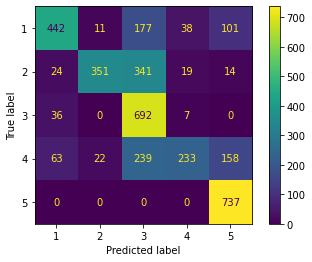

In [142]:
disp_model.plot() 

In [143]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [144]:
cm_clf_test

array([[769,   0,   0,   0,   0],
       [  0, 749,   0,   0,   0],
       [  0,   0, 735,   0,   0],
       [  0,   0,   0, 715,   0],
       [  0,   0,   0,   0, 737]], dtype=int64)

In [145]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

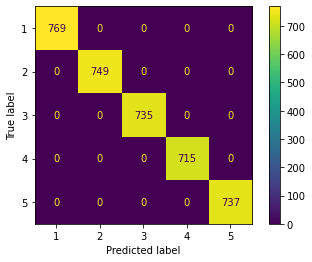

In [146]:
disp_clf.plot() 

In [147]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [148]:
cm_knn_test

array([[705,  16,   3,  36,   9],
       [  0, 745,   4,   0,   0],
       [  0,   0, 735,   0,   0],
       [  0,   0,   0, 715,   0],
       [  0,   0,   0,   0, 737]], dtype=int64)

In [149]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

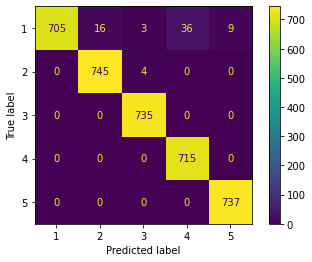

In [150]:
disp_knn.plot()

In [151]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000       769
           2      1.000     1.000     1.000       749
           3      1.000     1.000     1.000       735
           4      1.000     1.000     1.000       715
           5      1.000     1.000     1.000       737

    accuracy                          1.000      3705
   macro avg      1.000     1.000     1.000      3705
weighted avg      1.000     1.000     1.000      3705



In [152]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     0.917     0.957       769
           2      0.979     0.995     0.987       749
           3      0.991     1.000     0.995       735
           4      0.952     1.000     0.975       715
           5      0.988     1.000     0.994       737

    accuracy                          0.982      3705
   macro avg      0.982     0.982     0.982      3705
weighted avg      0.982     0.982     0.981      3705



In [153]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.782     0.575     0.663       769
           2      0.914     0.469     0.620       749
           3      0.478     0.941     0.634       735
           4      0.785     0.326     0.460       715
           5      0.730     1.000     0.844       737

    accuracy                          0.663      3705
   macro avg      0.738     0.662     0.644      3705
weighted avg      0.738     0.663     0.645      3705



In [154]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [155]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')